# 6 Term Frequency Analysis of AI-Related Disclosure

This notebook applies Bag-of-Words and TF-IDF weighting to the AI-related passages identified in notebook 02.

In [1]:
# Importing libraries and defining project paths

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Main project folders
data_folder = Path("../data")
text_folder = data_folder / "extracted_text"
outputs_folder = Path("../outputs")
evidence_folder = outputs_folder / "evidence_tables"
figures_folder = outputs_folder / "figures"
results_folder = outputs_folder / "results"
tfidf_folder = outputs_folder / "tfidf"

# Creating the folder for the new tables. The figures folder already exists.
tfidf_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

# Input files
mentions_file = evidence_folder / "ai_transparency_mentions_detailed.csv"
groups_file = results_folder / "companies_by_transparency_group.csv"

print("Mentions file:", mentions_file)
print("Groups file:", groups_file)
print("Extracted text folder:", text_folder)
print("TF-IDF output folder:", tfidf_folder)
print("Figures folder:", figures_folder)

Mentions file: ..\outputs\evidence_tables\ai_transparency_mentions_detailed.csv
Groups file: ..\outputs\results\companies_by_transparency_group.csv
Extracted text folder: ..\data\extracted_text
TF-IDF output folder: ..\outputs\tfidf
Figures folder: ..\outputs\figures


In [2]:
# Confirming that the required input files exist

required_files = {
    "AI transparency mentions": mentions_file,
    "Transparency group assignment": groups_file,
    "Extracted text folder": text_folder,
}

for file_name, file_path in required_files.items():
    if file_path.exists():
        print(f"\u2713 {file_name} found: {file_path}")
    else:
        print(f"\u2717 {file_name} not found: {file_path}")

✓ AI transparency mentions found: ..\outputs\evidence_tables\ai_transparency_mentions_detailed.csv
✓ Transparency group assignment found: ..\outputs\results\companies_by_transparency_group.csv
✓ Extracted text folder found: ..\data\extracted_text


## 1. Loading the matched passages and band assignment

In [3]:
# Loading the AI-related keyword matches and the transparency band assignment

mentions = pd.read_csv(
    mentions_file,
    dtype={"company_id": str}
)

groups = pd.read_csv(
    groups_file,
    dtype={"company_id": str}
)

# Preserving the three-digit company ID format
mentions["company_id"] = mentions["company_id"].str.zfill(3)
groups["company_id"] = groups["company_id"].str.zfill(3)

print("Matched passages:", len(mentions))
print("Firms represented:", mentions["company_id"].nunique())
print("Distinct keywords:", mentions["keyword"].nunique())

print("\nMentions columns:")
print(mentions.columns.tolist())

Matched passages: 1448
Firms represented: 20
Distinct keywords: 15

Mentions columns:
['company_id', 'company_name', 'report_year', 'source_file', 'category', 'keyword', 'search_variant', 'page_number', 'matched_text', 'context']


In [4]:
# Mapping the existing transparency groups onto short band labels

band_labels = {
    "High transparency": "high",
    "Moderate transparency": "moderate",
    "Limited transparency": "limited",
    "Low transparency": "low",
}

band_order = ["high", "moderate", "limited", "low"]

groups["band"] = groups["transparency_group"].map(band_labels)

if groups["band"].isna().any():
    unmapped = groups.loc[groups["band"].isna(), "transparency_group"].unique()
    raise ValueError(f"Unmapped transparency group values: {unmapped}")

firm_bands = groups[
    ["company_id", "company_name", "band", "final_score", "final_score_percentage"]
].copy()

print("Firms by band:")
print(firm_bands["band"].value_counts().reindex(band_order).to_string())

firm_bands.sort_values("final_score", ascending=False).reset_index(drop=True)

Firms by band:
band
high        6
moderate    5
limited     7
low         2


,company_id,company_name,band,final_score,final_score_percentage
0,004,NatWest Group plc,high,13,92.86
1,001,Barclays plc,high,12,85.71
2,003,Lloyds Banking Group plc,high,12,85.71
3,009,Admiral Group plc,high,11,78.57
4,002,HSBC Holdings plc,high,11,78.57
5,019,London Stock Exchange Group plc,high,11,78.57
6,020,Experian plc,moderate,10,71.43
7,005,Standard Chartered plc,moderate,10,71.43
8,006,Aviva plc,moderate,9,64.29
9,016,Funding Circle Holdings plc,moderate,9,64.29


## 2. Building one document per firm

Keyword matches generated overlapping context windows, which could artificially inflate term counts for firms with denser disclosures. To prevent this, overlapping spans were located within the original page text and merged, producing a deduplicated corpus containing only matched passages rather than full reports.

In [5]:
# Re-creating the page splitting and whitespace normalisation from notebook 02 

def split_text_into_pages(full_text):
    """
    Splits extracted report text using the page markers created
    in the text extraction notebook.
    """

    page_sections = re.split(
        r"===== PAGE (\d+) =====",
        full_text
    )

    pages = {}

    for index in range(1, len(page_sections), 2):
        page_number = int(page_sections[index])
        pages[page_number] = page_sections[index + 1]

    return pages


def normalise_whitespace(text):
    """
    Applies the same spacing clean-up that was applied when the context
    windows were originally extracted.
    """

    return re.sub(r"\s+", " ", text).strip()


# Loading and normalising every page that carries at least one match

normalised_pages = {}

for source_file in sorted(mentions["source_file"].unique()):

    raw_text = (text_folder / source_file).read_text(
        encoding="utf-8",
        errors="ignore"
    )

    for page_number, page_text in split_text_into_pages(raw_text).items():
        normalised_pages[(source_file, page_number)] = normalise_whitespace(page_text)

print("Report files read:", mentions["source_file"].nunique())
print("Pages normalised:", len(normalised_pages))

Report files read: 20
Pages normalised: 5332


In [6]:
# Locating each context window within its page to recover its character span

located_rows = []
unlocated_rows = []

for row in mentions.itertuples(index=False):

    page_text = normalised_pages.get((row.source_file, row.page_number), "")

    start = page_text.find(row.context)

    if start == -1:
        unlocated_rows.append(row)
        continue

    located_rows.append({
        "company_id": row.company_id,
        "source_file": row.source_file,
        "page_number": row.page_number,
        "start": start,
        "end": start + len(row.context),
        "context_length": len(row.context),
        "occurrences_on_page": page_text.count(row.context),
    })

spans = pd.DataFrame(located_rows)

print("Context windows located:", len(spans), "of", len(mentions))
print("Context windows not located:", len(unlocated_rows))
print(
    "Windows appearing more than once on their page:",
    int((spans["occurrences_on_page"] > 1).sum())
)

if len(unlocated_rows) > 0:
    raise ValueError(
        f"{len(unlocated_rows)} context windows could not be located in their page text."
    )

Context windows located: 1448 of 1448
Context windows not located: 0
Windows appearing more than once on their page: 0


In [7]:
# Merging overlapping spans within each page and assembling the firm documents

def merge_spans(span_pairs):
    """
    Merges a list of (start, end) character spans, combining any that
    overlap or touch. Returns the merged spans in order.
    """

    merged = []

    for start, end in sorted(span_pairs):

        if merged and start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    return [(start, end) for start, end in merged]


documents = {}
dedup_rows = []

for company_id, firm_spans in spans.groupby("company_id"):

    raw_characters = int(firm_spans["context_length"].sum())

    passages = []
    kept_characters = 0
    merged_span_count = 0

    page_keys = firm_spans[["source_file", "page_number"]].drop_duplicates()

    for source_file, page_number in page_keys.itertuples(index=False):

        page_rows = firm_spans[
            (firm_spans["source_file"] == source_file)
            & (firm_spans["page_number"] == page_number)
        ]

        page_text = normalised_pages[(source_file, page_number)]

        for start, end in merge_spans(zip(page_rows["start"], page_rows["end"])):
            passages.append(page_text[start:end])
            kept_characters += end - start
            merged_span_count += 1

    documents[company_id] = " ".join(passages)

    dedup_rows.append({
        "company_id": company_id,
        "context_windows": len(firm_spans),
        "merged_passages": merged_span_count,
        "raw_characters": raw_characters,
        "deduplicated_characters": kept_characters,
        "characters_removed": raw_characters - kept_characters,
        "percent_removed": round(
            (raw_characters - kept_characters) / raw_characters * 100, 1
        ) if raw_characters else 0.0,
    })

dedup_report = (
    pd.DataFrame(dedup_rows)
    .merge(firm_bands[["company_id", "company_name", "band"]], on="company_id")
    .sort_values("percent_removed", ascending=False)
    .reset_index(drop=True)
)

dedup_report = dedup_report[[
    "company_id", "company_name", "band", "context_windows", "merged_passages",
    "raw_characters", "deduplicated_characters", "characters_removed",
    "percent_removed",
]]

print("Documents built:", len(documents))

Documents built: 20


In [8]:
# Reporting how much duplicated text the merge removed per firm

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

total_raw = dedup_report["raw_characters"].sum()
total_kept = dedup_report["deduplicated_characters"].sum()
total_removed = total_raw - total_kept

print("CHARACTERS REMOVED BY DEDUPLICATION")
print("=" * 70)
print(f"Raw context characters:            {total_raw:>9,}")
print(f"After merging overlapping windows: {total_kept:>9,}")
print(f"Removed as duplicated text:        {total_removed:>9,} "
      f"({total_removed / total_raw * 100:.1f}%)")
print()
print(f"Largest reduction:  {dedup_report.iloc[0]['company_name']} "
      f"({dedup_report.iloc[0]['percent_removed']:.1f}%)")
print(f"Smallest reduction: {dedup_report.iloc[-1]['company_name']} "
      f"({dedup_report.iloc[-1]['percent_removed']:.1f}%)")

dedup_file = tfidf_folder / "corpus_deduplication_report.csv"
dedup_report.to_csv(dedup_file, index=False)
print("\nSaved to:", dedup_file)

dedup_report

CHARACTERS REMOVED BY DEDUPLICATION
Raw context characters:              451,193
After merging overlapping windows:   328,574
Removed as duplicated text:          122,619 (27.2%)

Largest reduction:  IntegraFin Holdings plc (53.7%)
Smallest reduction: CMC Markets plc (0.0%)

Saved to: ..\outputs\tfidf\corpus_deduplication_report.csv


,company_id,company_name,band,context_windows,merged_passages,raw_characters,deduplicated_characters,characters_removed,percent_removed
0,013,IntegraFin Holdings plc,limited,11,3,3758,1739,2019,53.7
1,009,Admiral Group plc,high,103,51,36079,23056,13023,36.1
2,001,Barclays plc,high,249,122,75602,50965,24637,32.6
3,016,Funding Circle Holdings plc,moderate,104,53,33410,22606,10804,32.3
4,014,Wise plc,limited,29,16,9562,6495,3067,32.1
5,007,Legal & General Group plc,limited,51,28,15967,11317,4650,29.1
6,005,Standard Chartered plc,moderate,94,50,32251,23132,9119,28.3
7,004,NatWest Group plc,high,210,124,64259,46514,17745,27.6
8,020,Experian plc,moderate,74,47,23492,17210,6282,26.7
9,002,HSBC Holdings plc,high,100,67,31905,24011,7894,24.7


Deduplication removes roughly a quarter of the raw context text, and the reduction is uneven, that is firms whose matches cluster densely on a few pages lose proportionally far more than firms whose handful of matches are scattered.

## 3. Preprocessing
Text is lowercased, digits and punctuation are stripped, and English stopwords are removed

In [9]:
# Defining the preprocessing applied inside both vectorisers

def clean_text(text):
    """
    Lowercases the text and replaces every character that is not a letter
    with a space, which removes punctuation and digits while keeping
    hyphenated and possessive forms apart as separate tokens.
    """

    text = text.lower()
    text = re.sub(r"[^a-z]+", " ", text)

    return text


# Single letters and are dropped
token_pattern = r"(?u)\b[a-z]{2,}\b"

vectoriser_settings = dict(
    preprocessor=clean_text,
    token_pattern=token_pattern,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

# Fixing the document order 
firm_ids = sorted(documents)
corpus = [documents[company_id] for company_id in firm_ids]

firm_names = (
    firm_bands.set_index("company_id")
    .loc[firm_ids, "company_name"]
    .tolist()
)

print("Documents in corpus:", len(corpus))
print("Preprocessing: lowercase, letters only, English stopwords removed")
print("Terms: unigrams and bigrams, no stemming or lemmatisation")

# Showing the effect of cleaning on a short extract
sample = corpus[0][:220]
print("\nBefore cleaning:\n", sample)
print("\nAfter cleaning:\n", clean_text(sample))

Documents in corpus: 20
Preprocessing: lowercase, letters only, English stopwords removed
Terms: unigrams and bigrams, no stemming or lemmatisation

Before cleaning:
 class customer experience; and delivering best You can find out more about how the Directors have had regard to the matters set out in Section embracing artificial intelligence (AI) and other new in classservicecustomer 

After cleaning:
 class customer experience and delivering best you can find out more about how the directors have had regard to the matters set out in section embracing artificial intelligence ai and other new in classservicecustomer 


## 4. Fitting the Bag-of-Words and TF-IDF vectorisers

In [10]:
# Fitting both vectorisers on the identical corpus

count_vectoriser = CountVectorizer(**vectoriser_settings)
count_matrix = count_vectoriser.fit_transform(corpus)

tfidf_vectoriser = TfidfVectorizer(sublinear_tf=True, **vectoriser_settings)
tfidf_matrix = tfidf_vectoriser.fit_transform(corpus)

count_terms = count_vectoriser.get_feature_names_out()
tfidf_terms = tfidf_vectoriser.get_feature_names_out()


assert list(count_terms) == list(tfidf_terms), "Vectoriser vocabularies differ"

terms = count_terms

print("Bag-of-Words matrix:", count_matrix.shape)
print("TF-IDF matrix:      ", tfidf_matrix.shape)
print("Retained vocabulary:", len(terms), "terms")

unigrams = sum(1 for term in terms if " " not in term)
print(f"  unigrams: {unigrams}")
print(f"  bigrams:  {len(terms) - unigrams}")

# Dense frames indexed by firm
count_frame = pd.DataFrame(
    count_matrix.toarray(), index=firm_ids, columns=terms
)

tfidf_frame = pd.DataFrame(
    tfidf_matrix.toarray(), index=firm_ids, columns=terms
)

count_frame.iloc[:5, :8]

Bag-of-Words matrix: (20, 3820)
TF-IDF matrix:       (20, 3820)
Retained vocabulary: 3820 terms
  unigrams: 2277
  bigrams:  1543


,ability,ability access,ability deliver,ability scale,able,academy,accelerate,accelerated
001,5,2,0,0,1,0,0,0
002,1,0,0,0,0,4,0,1
003,1,0,0,0,0,0,1,1
004,3,1,0,0,1,0,0,1
005,3,0,0,0,0,1,2,1


## 5. Diagnostics

The two diagnostics below record the limits of the vectorisation. They are
printed in full rather than summarised, because both bear directly on how much
weight the term rankings can carry.

### Document length

A TF-IDF vector estimated from a very short document is unstable: a handful of
tokens determines the whole profile, and a single additional sentence would
change it substantially. Firms falling below 100 tokens are flagged so that
their rows in the tables and heatmap below are read with that in mind.

In [11]:
# Measuring document length at three stages of preprocessing

analyser = count_vectoriser.build_analyzer()

length_rows = []

for company_id in firm_ids:

    document = documents[company_id]

    all_tokens = re.findall(token_pattern, clean_text(document))

    content_tokens = [term for term in analyser(document) if " " not in term]

    vocabulary = set(terms)
    retained_tokens = [term for term in content_tokens if term in vocabulary]

    length_rows.append({
        "company_id": company_id,
        "characters": len(document),
        "tokens_before_stopwords": len(all_tokens),
        "tokens": len(content_tokens),
        "tokens_in_vocabulary": len(retained_tokens),
        "distinct_terms": int((count_frame.loc[company_id] > 0).sum()),
    })

doc_lengths = (
    pd.DataFrame(length_rows)
    .merge(firm_bands[["company_id", "company_name", "band"]], on="company_id")
)

doc_lengths["unstable_vector"] = doc_lengths["tokens"] < 100

doc_lengths = doc_lengths[[
    "company_id", "company_name", "band", "characters",
    "tokens_before_stopwords", "tokens", "tokens_in_vocabulary",
    "distinct_terms", "unstable_vector",
]].sort_values("tokens", ascending=False).reset_index(drop=True)

length_file = tfidf_folder / "document_length_diagnostics.csv"
doc_lengths.to_csv(length_file, index=False)

print("DOCUMENT LENGTH IN TOKENS (after stopword removal)")
print("=" * 78)
print(doc_lengths.to_string(index=False))

flagged = doc_lengths[doc_lengths["unstable_vector"]]

print()
if len(flagged) == 0:
    print("No firm falls below the 100-token threshold.")
else:
    print(f"UNSTABLE VECTORS \u2014 {len(flagged)} firm(s) below 100 tokens:")
    for row in flagged.itertuples(index=False):
        print(f"  {row.company_id} {row.company_name}: {row.tokens} tokens "
              f"({row.band} band). Term weights for this firm are not reliable.")

print("\nMedian document length:", int(doc_lengths["tokens"].median()), "tokens")
print("Ratio longest to shortest:",
      round(doc_lengths["tokens"].max() / max(doc_lengths["tokens"].min(), 1), 1))
print("\nSaved to:", length_file)

DOCUMENT LENGTH IN TOKENS (after stopword removal)
company_id                    company_name     band  characters  tokens_before_stopwords  tokens  tokens_in_vocabulary  distinct_terms  unstable_vector
       001                    Barclays plc     high       51086                     7444    4560                  3598            1749            False
       004               NatWest Group plc     high       46637                     6553    4130                  3324            1733            False
       019 London Stock Exchange Group plc     high       30499                     4305    2841                  2333            1191            False
       002               HSBC Holdings plc     high       24077                     3448    2181                  1768            1146            False
       009               Admiral Group plc     high       23106                     3341    2108                  1766            1156            False
       005          Standard Chartere

### 5.2 Document frequency of retained terms

With only twenty documents, document frequency can take just nineteen distinct values between the `min_df` and `max_df` cut-offs, so the IDF component is very coarse. Many terms share an identical IDF and are separated in the rankings only by their term frequency. The full distribution is printed below so the granularity is visible rather than assumed.

In [12]:
# Recording the document frequency of every retained term

document_frequency = (count_frame > 0).sum(axis=0)

# IDF applied
idf_values = pd.Series(tfidf_vectoriser.idf_, index=terms)

term_diagnostics = pd.DataFrame({
    "term": terms,
    "term_type": ["bigram" if " " in term else "unigram" for term in terms],
    "document_frequency": document_frequency.values,
    "document_frequency_pct": (document_frequency.values / len(firm_ids) * 100).round(1),
    "idf": idf_values.values.round(4),
    "total_count": count_frame.sum(axis=0).values,
}).sort_values(
    ["document_frequency", "total_count"], ascending=[False, False]
).reset_index(drop=True)

df_file = tfidf_folder / "term_document_frequency.csv"
term_diagnostics.to_csv(df_file, index=False)

print("DOCUMENT FREQUENCY DISTRIBUTION OF RETAINED TERMS")
print("=" * 78)
print(f"Documents in corpus: {len(firm_ids)}")
print(f"Retained terms:      {len(terms)}")
print(f"Distinct df values:  {term_diagnostics['document_frequency'].nunique()}")
print(f"Distinct idf values: {term_diagnostics['idf'].nunique()}")
print()

frequency_distribution = (
    term_diagnostics.groupby("document_frequency")
    .agg(
        terms=("term", "count"),
        idf=("idf", "first"),
    )
    .reset_index()
    .sort_values("document_frequency", ascending=False)
)

frequency_distribution["share_of_vocabulary_pct"] = (
    frequency_distribution["terms"] / len(terms) * 100
).round(1)

print("Terms at each document frequency:")
print(frequency_distribution.to_string(index=False))

single_df = int((term_diagnostics["document_frequency"] == 2).sum())
print()
print(f"Terms appearing in exactly 2 documents: {single_df} "
      f"({single_df / len(terms) * 100:.1f}% of the vocabulary)")
print("Highest IDF the per-firm rankings despite resting on the thinnest evidence.")
print("\nSaved to:", df_file)

DOCUMENT FREQUENCY DISTRIBUTION OF RETAINED TERMS
Documents in corpus: 20
Retained terms:      3820
Distinct df values:  17
Distinct idf values: 17

Terms at each document frequency:
 document_frequency  terms    idf  share_of_vocabulary_pct
                 18     10 1.1001                      0.3
                 17     15 1.1542                      0.4
                 16     13 1.2113                      0.3
                 15     28 1.2719                      0.7
                 14     38 1.3365                      1.0
                 13     34 1.4055                      0.9
                 12     56 1.4796                      1.5
                 11     42 1.5596                      1.1
                 10     66 1.6466                      1.7
                  9     75 1.7419                      2.0
                  8    116 1.8473                      3.0
                  7    128 1.9651                      3.4
                  6    159 2.0986                 

Terms at each document frequency:
 document_frequency  terms    idf  share_of_vocabulary_pct
                 18     10 1.1001                      0.3
                 17     15 1.1542                      0.4
                 16     13 1.2113                      0.3
                 15     28 1.2719                      0.7
                 14     38 1.3365                      1.0
                 13     34 1.4055                      0.9
                 12     56 1.4796                      1.5
                 11     42 1.5596                      1.1
                 10     66 1.6466                      1.7
                  9     75 1.7419                      2.0
                  8    116 1.8473                      3.0
                  7    128 1.9651                      3.4
                  6    159 2.0986                      4.2
                  5    246 2.2528                      6.4
                  4    335 2.4351                      8.8
                  3   

In [13]:
# Printing the document frequency of every retained term
# The full list is printed to inspect closely

print("DOCUMENT FREQUENCY OF EVERY RETAINED TERM")
print("=" * 78)

with pd.option_context("display.max_rows", None):
    print(
        term_diagnostics[
            ["term", "term_type", "document_frequency", "document_frequency_pct", "idf", "total_count"]
        ].to_string(index=False)
    )

DOCUMENT FREQUENCY OF EVERY RETAINED TERM
                      term term_type  document_frequency  document_frequency_pct    idf  total_count
                     group   unigram                  18                    90.0 1.1001          336
                       use   unigram                  18                    90.0 1.1001          187
                management   unigram                  18                    90.0 1.1001          155
              intelligence   unigram                  18                    90.0 1.1001          140
                    growth   unigram                  18                    90.0 1.1001          104
                      year   unigram                  18                    90.0 1.1001           88
               operational   unigram                  18                    90.0 1.1001           87
                  continue   unigram                  18                    90.0 1.1001           68
                 processes   unigram             

                      term term_type  document_frequency  document_frequency_pct    idf  total_count
                     group   unigram                  18                    90.0 1.1001          336
                       use   unigram                  18                    90.0 1.1001          187
                management   unigram                  18                    90.0 1.1001          155
              intelligence   unigram                  18                    90.0 1.1001          140
                    growth   unigram                  18                    90.0 1.1001          104
                      year   unigram                  18                    90.0 1.1001           88
               operational   unigram                  18                    90.0 1.1001           87
                  continue   unigram                  18                    90.0 1.1001           68
                 processes   unigram                  18                    90.0 1.1001    

## 6. Output 1 — Top 15 TF-IDF terms per firm

In [14]:
# Extracting the fifteen highest weighted terms for each firm

top_n_per_firm = 15

per_firm_rows = []

for company_id in firm_ids:

    firm_scores = tfidf_frame.loc[company_id]
    firm_scores = firm_scores[firm_scores > 0]

    # Ties are broken alphabetically so the ordering is reproducible
    ranked = firm_scores.sort_values(ascending=False, kind="mergesort").head(top_n_per_firm)

    for rank, (term, score) in enumerate(ranked.items(), start=1):
        per_firm_rows.append({
            "company_id": company_id,
            "term": term,
            "score": round(float(score), 6),
            "rank": rank,
        })

top_terms_per_firm = (
    pd.DataFrame(per_firm_rows)
    .merge(firm_bands[["company_id", "company_name", "band"]], on="company_id")
)

top_terms_per_firm = top_terms_per_firm[
    ["company_id", "company_name", "band", "term", "score", "rank"]
].sort_values(["company_id", "rank"]).reset_index(drop=True)

# Flagging rows belonging to firms with an unstable vector
unstable_ids = set(doc_lengths.loc[doc_lengths["unstable_vector"], "company_id"])
top_terms_per_firm["unstable_vector"] = top_terms_per_firm["company_id"].isin(unstable_ids)

top_terms_file = tfidf_folder / "top_terms_per_firm.csv"
top_terms_per_firm.to_csv(top_terms_file, index=False)

print("Rows written:", len(top_terms_per_firm))
print("Firms covered:", top_terms_per_firm["company_id"].nunique())
print("Saved to:", top_terms_file)

top_terms_per_firm.head(30)

Rows written: 300
Firms covered: 20
Saved to: ..\outputs\tfidf\top_terms_per_firm.csv


,company_id,company_name,band,term,score,rank,unstable_vector
0,001,Barclays plc,high,eu,0.061652,1,False
1,001,Barclays plc,high,ai technologies,0.060617,2,False
2,001,Barclays plc,high,ai group,0.058241,3,False
3,001,Barclays plc,high,harm,0.058241,4,False
4,001,Barclays plc,high,require,0.058241,5,False
5,001,Barclays plc,high,eu ai,0.055194,6,False
6,001,Barclays plc,high,laws,0.053987,7,False
7,001,Barclays plc,high,regime,0.052554,8,False
8,001,Barclays plc,high,ai act,0.051589,9,False
9,001,Barclays plc,high,ai policy,0.051589,10,False


In [15]:
# Displaying the leading terms for each firm in a compact form

print("TOP TF-IDF TERMS BY FIRM")
print("=" * 78)

for company_id in firm_ids:

    firm_rows = top_terms_per_firm[top_terms_per_firm["company_id"] == company_id]
    firm_name = firm_rows.iloc[0]["company_name"]
    band = firm_rows.iloc[0]["band"]
    flag = "  [UNSTABLE VECTOR]" if company_id in unstable_ids else ""

    print(f"\n{company_id} {firm_name} ({band}){flag}")
    print("  " + ", ".join(firm_rows["term"].head(10)))

TOP TF-IDF TERMS BY FIRM

001 Barclays plc (high)
  eu, ai technologies, ai group, harm, require, eu ai, laws, regime, ai act, ai policy

002 HSBC Holdings plc (high)
  holdings, human rights, holdings plc, model risk, academy, deregulation, salient, digital assets, genai, currencies

003 Lloyds Banking Group plc (high)
  gen, gen ai, dive, deep dive, million, shift, colleague, deep, digital ai, propositions

004 NatWest Group plc (high)
  backed, family, accessibility, bank, challenged, climate transition, code conduct, internally, responses, spotlight

005 Standard Chartered plc (moderate)
  cent, bank, hong, hong kong, kong, supply, chartered, people leaders, race, supply chains

006 Aviva plc (moderate)
  retirement, wealth, subsidiaries, achieved, advancing, canada, incorporated, ireland, personal lines, uk ireland

007 Legal & General Group plc (limited)
  retirement, read, ordinary, fund, ai developments, hedging, including data, ai risk, category, divisional

008 M&G plc (limit

## 7. Output 2 — Top 20 raw-frequency terms across the corpus

In [16]:
# Ranking terms by raw occurrence count in the Bag-of-Words matrix

corpus_counts = count_frame.sum(axis=0)

top_frequency_terms = pd.DataFrame({
    "term": corpus_counts.index,
    "total_count": corpus_counts.values,
    "document_frequency": document_frequency.reindex(corpus_counts.index).values,
}).sort_values(
    ["total_count", "term"], ascending=[False, True]
).head(20).reset_index(drop=True)

top_frequency_terms.insert(0, "rank", range(1, len(top_frequency_terms) + 1))

top_frequency_terms["term_type"] = [
    "bigram" if " " in term else "unigram" for term in top_frequency_terms["term"]
]

top_frequency_terms["firms_using_term"] = top_frequency_terms["document_frequency"]
top_frequency_terms["mean_count_per_firm"] = (
    top_frequency_terms["total_count"] / len(firm_ids)
).round(1)

top_frequency_terms = top_frequency_terms[[
    "rank", "term", "term_type", "total_count",
    "firms_using_term", "mean_count_per_firm",
]]

frequency_file = tfidf_folder / "top_frequency_terms_corpus.csv"
top_frequency_terms.to_csv(frequency_file, index=False)

print("TOP 20 TERMS BY RAW FREQUENCY (Bag-of-Words)")
print("=" * 60)
print(top_frequency_terms.to_string(index=False))
print("\nSaved to:", frequency_file)

TOP 20 TERMS BY RAW FREQUENCY (Bag-of-Words)
 rank                    term term_type  total_count  firms_using_term  mean_count_per_firm
    1                   group   unigram          336                18                 16.8
    2                    data   unigram          314                17                 15.7
    3                     use   unigram          187                18                  9.4
    4              technology   unigram          186                16                  9.3
    5                     new   unigram          176                17                  8.8
    6               customers   unigram          167                15                  8.4
    7                customer   unigram          161                17                  8.0
    8              management   unigram          155                18                  7.8
    9            intelligence   unigram          140                18                  7.0
   10                 digital   uni

Raw frequency reflects the vocabulary of the corpus as a whole and is dominated by the search terms themselves. It is reported for completeness and as a check on the TF-IDF weighting.

## 8. Output 3 — Mean TF-IDF by transparency band

Mean term weights are compared across the four existing bands, and the terms separating the high band from the pooled limited and low bands are extracted. The limited and low bands are pooled because the low band contains only two firms, one of which contributes a single matched passage.

This comparison is descriptive as it shows which words accompany the disclosures of firms in each band.

In [17]:
# Calculating the mean TF-IDF weight of every term within each band

band_lookup = firm_bands.set_index("company_id")["band"]
document_bands = band_lookup.loc[firm_ids]

band_means = (
    tfidf_frame
    .groupby(document_bands.values, observed=True)
    .mean()
    .reindex(band_order)
)

band_mean_table = band_means.T.reset_index()
band_mean_table.columns = ["term"] + [f"mean_tfidf_{band}" for band in band_order]

band_mean_table["term_type"] = [
    "bigram" if " " in term else "unigram" for term in band_mean_table["term"]
]

band_mean_table = band_mean_table.round(6).sort_values(
    "mean_tfidf_high", ascending=False
).reset_index(drop=True)

band_file = tfidf_folder / "mean_tfidf_by_band.csv"
band_mean_table.to_csv(band_file, index=False)

print("Firms per band:")
print(document_bands.value_counts().reindex(band_order).to_string())
print("\nTerms scored:", len(band_mean_table))
print("Saved to:", band_file)

band_mean_table.head(15)

Firms per band:
band
high        6
moderate    5
limited     7
low         2

Terms scored: 3820
Saved to: ..\outputs\tfidf\mean_tfidf_by_band.csv


,term,mean_tfidf_high,mean_tfidf_moderate,mean_tfidf_limited,mean_tfidf_low,term_type
0,data,0.044700,0.044302,0.038438,0.000000,unigram
1,customers,0.042870,0.023774,0.033279,0.000000,unigram
2,uk,0.042565,0.022445,0.011865,0.000000,unigram
3,group,0.041742,0.038362,0.043796,0.039320,unigram
4,colleagues,0.041292,0.018826,0.009775,0.000000,unigram
5,technology,0.040217,0.034798,0.040303,0.026258,unigram
6,model,0.039491,0.019379,0.026645,0.000000,unigram
7,models,0.037677,0.024052,0.009342,0.000000,unigram
8,agentic,0.037361,0.016239,0.003605,0.000000,unigram
9,innovation,0.037249,0.045576,0.006687,0.000000,unigram


In [18]:
# Identifying the terms separating the high band from the limited and low bands
# The limited and low firms are pooled into a single group of firms and the mean taken across those firms so each firm carries equal weight.

high_mask = (document_bands == "high").values
lower_mask = document_bands.isin(["limited", "low"]).values

high_mean = tfidf_frame.loc[high_mask].mean()
lower_mean = tfidf_frame.loc[lower_mask].mean()

gap_table = pd.DataFrame({
    "term": terms,
    "mean_tfidf_high": high_mean.values.round(6),
    "mean_tfidf_limited_low": lower_mean.values.round(6),
    "gap": (high_mean.values - lower_mean.values).round(6),
    "firms_high_band": (tfidf_frame.loc[high_mask] > 0).sum(axis=0).values,
    "firms_limited_low_band": (tfidf_frame.loc[lower_mask] > 0).sum(axis=0).values,
    "document_frequency": document_frequency.values,
})

gap_table["term_type"] = ["bigram" if " " in term else "unigram" for term in gap_table["term"]]

top_gap = gap_table.sort_values(
    ["gap", "term"], ascending=[False, True]
).head(15).reset_index(drop=True)

top_gap.insert(0, "rank", range(1, len(top_gap) + 1))

gap_file = tfidf_folder / "band_gap_terms.csv"
top_gap.to_csv(gap_file, index=False)

print("FIFTEEN LARGEST GAPS: HIGH BAND vs POOLED LIMITED + LOW BANDS")
print(f"(high n={int(high_mask.sum())} firms, limited+low n={int(lower_mask.sum())} firms)")
print("=" * 78)
print(
    top_gap[[
        "rank", "term", "term_type", "mean_tfidf_high",
        "mean_tfidf_limited_low", "gap", "firms_high_band", "firms_limited_low_band",
    ]].to_string(index=False)
)
print("\nSaved to:", gap_file)

FIFTEEN LARGEST GAPS: HIGH BAND vs POOLED LIMITED + LOW BANDS
(high n=6 firms, limited+low n=9 firms)
 rank       term term_type  mean_tfidf_high  mean_tfidf_limited_low      gap  firms_high_band  firms_limited_low_band
    1 agentic ai    bigram         0.035743                0.000000 0.035743                6                       0
    2    agentic   unigram         0.037361                0.002804 0.034557                6                       1
    3 colleagues   unigram         0.041292                0.007603 0.033689                6                       2
    4         uk   unigram         0.042565                0.009229 0.033336                6                       2
    5       bank   unigram         0.033141                0.000000 0.033141                4                       0
    6    example   unigram         0.032382                0.000000 0.032382                6                       0
    7 innovation   unigram         0.037249                0.005201 0.03

## 9. Output 4 — Heatmap of the leading terms by firm

The terms shown are the twenty-five carrying the greatest total TF-IDF weight across the corpus. Firms are ordered by their existing transparency score so that any banding in the vocabulary is visible.

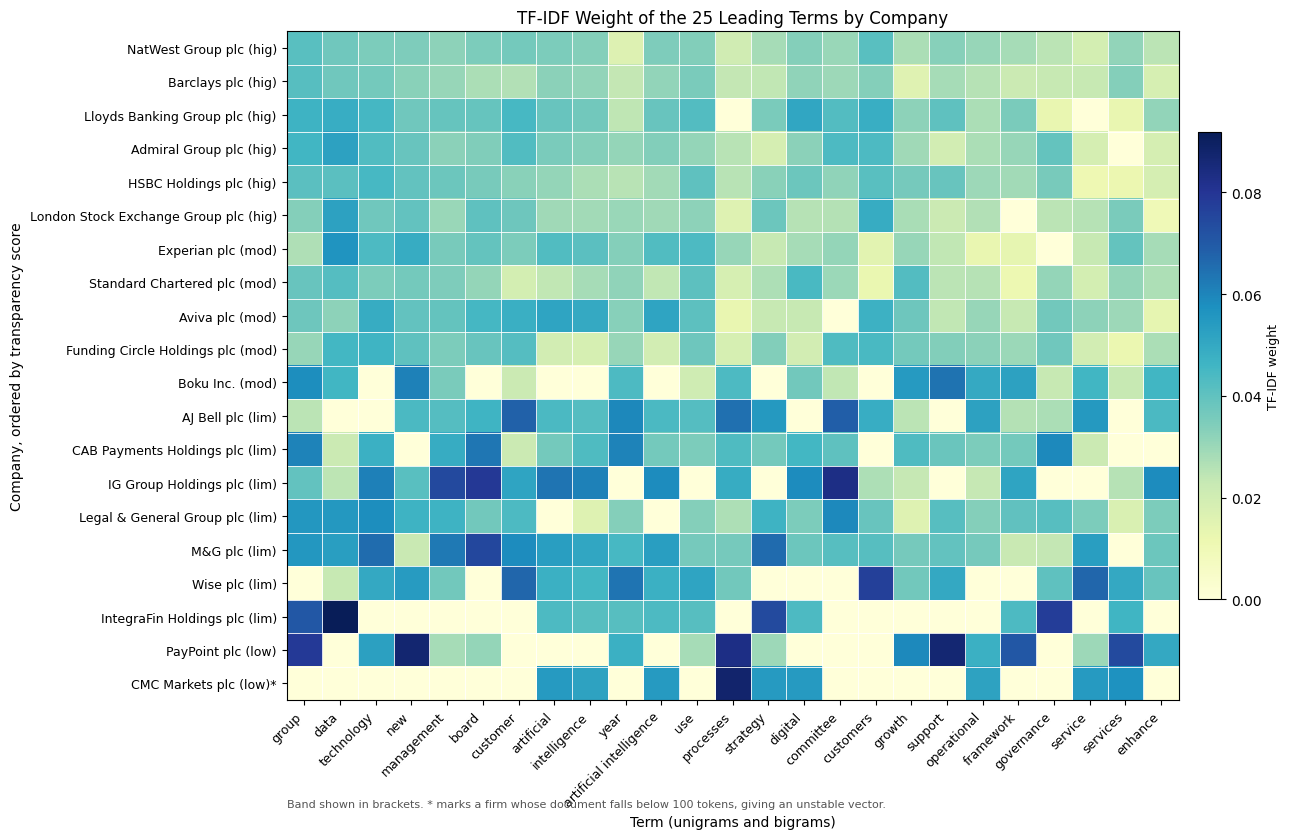

Figure saved to: ..\outputs\figures\tfidf_top_terms_heatmap.png


In [19]:
# Selecting the leading terms and drawing the heatmap

heatmap_term_count = 25

leading_terms = (
    tfidf_frame.sum(axis=0)
    .sort_values(ascending=False, kind="mergesort")
    .head(heatmap_term_count)
    .index.tolist()
)

# Ordering firms by their existing transparency score highest first
firm_order = (
    firm_bands[firm_bands["company_id"].isin(firm_ids)]
    .sort_values(["final_score", "company_name"], ascending=[False, True])
)

heatmap_data = tfidf_frame.loc[firm_order["company_id"], leading_terms]


row_labels = [
    f"{row.company_name} ({row.band[:3]}){'*' if row.company_id in unstable_ids else ''}"
    for row in firm_order.itertuples(index=False)
]

fig, ax = plt.subplots(figsize=(13, 8.5))

mesh = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="YlGnBu",
    vmin=0,
)

ax.set_xticks(np.arange(len(leading_terms)))
ax.set_xticklabels(leading_terms, rotation=45, ha="right", fontsize=9)

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

ax.set_xlabel("Term (unigrams and bigrams)")
ax.set_ylabel("Company, ordered by transparency score")
ax.set_title(
    f"TF-IDF Weight of the {heatmap_term_count} Leading Terms by Company"
)

# Gridlines between cells
ax.set_xticks(np.arange(-0.5, len(leading_terms), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", length=0)

colour_bar = fig.colorbar(mesh, ax=ax, fraction=0.025, pad=0.02)
colour_bar.set_label("TF-IDF weight", fontsize=9)

ax.text(
    0, -0.16,
    "Band shown in brackets. * marks a firm whose document falls below "
    "100 tokens, giving an unstable vector.",
    transform=ax.transAxes,
    fontsize=8,
    color="#555555",
)

plt.tight_layout()

heatmap_file = figures_folder / "tfidf_top_terms_heatmap.png"

fig.savefig(
    heatmap_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", heatmap_file)

In [20]:
# Saving the heatmap values so the figure can be reproduced from a table

heatmap_table = heatmap_data.copy()
heatmap_table.insert(0, "company_name", firm_order["company_name"].values)
heatmap_table.insert(1, "band", firm_order["band"].values)
heatmap_table = heatmap_table.round(6).reset_index().rename(columns={"index": "company_id"})

heatmap_data_file = tfidf_folder / "heatmap_top_terms_by_firm.csv"
heatmap_table.to_csv(heatmap_data_file, index=False)

print("Saved to:", heatmap_data_file)
print("Shape:", heatmap_table.shape)

heatmap_table.iloc[:, :8]

Saved to: ..\outputs\tfidf\heatmap_top_terms_by_firm.csv
Shape: (20, 28)


,company_id,company_name,band,group,data,technology,new,management
0,004,NatWest Group plc,high,0.041294,0.037070,0.035103,0.034744,0.032208
1,001,Barclays plc,high,0.041881,0.037056,0.036553,0.032981,0.030845
2,003,Lloyds Banking Group plc,high,0.046882,0.048627,0.044984,0.037024,0.038939
3,009,Admiral Group plc,high,0.045637,0.052095,0.043011,0.038515,0.032440
4,002,HSBC Holdings plc,high,0.041123,0.041122,0.044615,0.039535,0.037683
5,019,London Stock Exchange Group plc,high,0.033633,0.052228,0.037033,0.039549,0.030163
6,020,Experian plc,moderate,0.026903,0.056193,0.043468,0.048944,0.035789
7,005,Standard Chartered plc,moderate,0.038549,0.042067,0.035076,0.036272,0.034573
8,006,Aviva plc,moderate,0.037648,0.031995,0.049039,0.039498,0.039354
9,016,Funding Circle Holdings plc,moderate,0.030695,0.045500,0.046406,0.040199,0.035153


## 10. Summary of outputs

In [21]:
# Listing everything this notebook wrote

written_files = [
    tfidf_folder / "corpus_deduplication_report.csv",
    tfidf_folder / "document_length_diagnostics.csv",
    tfidf_folder / "term_document_frequency.csv",
    tfidf_folder / "top_terms_per_firm.csv",
    tfidf_folder / "top_frequency_terms_corpus.csv",
    tfidf_folder / "mean_tfidf_by_band.csv",
    tfidf_folder / "band_gap_terms.csv",
    tfidf_folder / "heatmap_top_terms_by_firm.csv",
    figures_folder / "tfidf_top_terms_heatmap.png",
]

print("FILES WRITTEN BY THIS NOTEBOOK")
print("=" * 70)

for file_path in written_files:
    status = "\u2713" if file_path.exists() else "\u2717"
    print(f"{status} {file_path}")

print()
print("No existing table, figure or score was modified by this notebook.")

FILES WRITTEN BY THIS NOTEBOOK
✓ ..\outputs\tfidf\corpus_deduplication_report.csv
✓ ..\outputs\tfidf\document_length_diagnostics.csv
✓ ..\outputs\tfidf\term_document_frequency.csv
✓ ..\outputs\tfidf\top_terms_per_firm.csv
✓ ..\outputs\tfidf\top_frequency_terms_corpus.csv
✓ ..\outputs\tfidf\mean_tfidf_by_band.csv
✓ ..\outputs\tfidf\band_gap_terms.csv
✓ ..\outputs\tfidf\heatmap_top_terms_by_firm.csv
✓ ..\outputs\figures\tfidf_top_terms_heatmap.png

No existing table, figure or score was modified by this notebook.


## 11. Interpretation
This analysis focuses on deduplicated AI-keyword context windows rather than complete annual reports, revealing highly unequal and occasionally noisy firm-level corpora. Application of TF-IDF identifies regulatory, operational, governance, and product-related themes; however, the resulting rankings are influenced by document length, sector composition, and the presence of rare terms. These findings are exploratory and are intended to complement, rather than serve as, measures of transparency disclosure scores.